In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
dir = os.getcwd()

# Feature extraction

In [3]:
data = pd.read_excel( f"{dir}/DMT Questionnaires and Subject data.xlsx",
                     sheet_name = "Subject data",
                     skiprows = [3, 6, 9, 14, 17, 24, 32],
                     index_col = False )
data.loc[data['DMT - Previous Experiences'] == 1, ['DMT - Previous Experiences']] = 0
data.loc[data['DMT - Previous Experiences'] > 1, ['DMT - Previous Experiences']] = 1
dmt_exp = list( data["DMT - Previous Experiences"].values )


In [4]:
one_time_group = data.loc[data['DMT - Previous Experiences'] == 0]
multi_time_group = data.loc[data['DMT - Previous Experiences'] == 1]
display( one_time_group.head() )
display( multi_time_group.head() )

,Subject,Age,Weight (kg),Male(0) / Female(1),Ayahuasca - Previous Experiences,DMT - Previous Experiences
4,S7,33,55.0,1,NaN,0
5,S8,22,75.0,0,NaN,0
9,S13,37,73.0,0,NaN,0
10,S15,35,84.0,0,1.0,0
11,S16,38,85.0,0,NaN,0


,Subject,Age,Weight (kg),Male(0) / Female(1),Ayahuasca - Previous Experiences,DMT - Previous Experiences
0,S1,37,69.0,0,NaN,1
1,S2,35,115.0,0,NaN,1
2,S4,31,51.0,1,NaN,1
3,S5,32,78.0,0,NaN,1
6,S10,28,72.0,0,NaN,1


Read precalculated PSD and calculate averge value per band and subject

In [5]:
aal90_labels = pd.read_csv( f"{dir}/PSD/AAL90.csv", delimiter = ";", index_col = 0 )["Label"].to_list()
pre_alpha = pd.read_csv( f"{dir}/PSD/alpha.csv", names = aal90_labels, skiprows=[10] )
pre_beta = pd.read_csv( f"{dir}/PSD/beta.csv", names = aal90_labels, skiprows=[10] )
pre_delta = pd.read_csv( f"{dir}/PSD/delta.csv", names = aal90_labels, skiprows=[10] )
pre_gamma1 = pd.read_csv( f"{dir}/PSD/gamma1.csv", names = aal90_labels, skiprows=[10] )
pre_gamma2 = pd.read_csv( f"{dir}/PSD/gamma2.csv", names = aal90_labels, skiprows=[10] )
pre_theta = pd.read_csv( f"{dir}/PSD/theta.csv", names = aal90_labels, skiprows=[10] )
dmt_alpha = pd.read_csv( f"{dir}/PSD/DMT_alpha.csv", names = aal90_labels, skiprows=[10] )
dmt_beta = pd.read_csv( f"{dir}/PSD/DMT_beta.csv", names = aal90_labels, skiprows=[10] )
dmt_delta = pd.read_csv( f"{dir}/PSD/DMT_delta.csv", names = aal90_labels, skiprows=[10] )
dmt_gamma1 = pd.read_csv( f"{dir}/PSD/DMT_gamma1.csv", names = aal90_labels, skiprows=[10] )
dmt_gamma2 = pd.read_csv( f"{dir}/PSD/DMT_gamma2.csv", names = aal90_labels, skiprows=[10] )
dmt_theta = pd.read_csv( f"{dir}/PSD/DMT_theta.csv", names = aal90_labels, skiprows=[10] )

In [6]:
pre_alpha_m = list( pre_alpha.mean( axis=1 ).round( 3 ) )
pre_beta_m = list ( pre_beta.mean( axis=1 ).round( 3 ) )
pre_delta_m = list( pre_delta.mean( axis=1 ).round( 3 ) )
pre_gamma1_m = list( pre_gamma1.mean( axis=1 ).round( 3 ) )
pre_gamma2_m = list( pre_gamma2.mean( axis=1 ).round( 3 ) )
pre_theta_m = list( pre_theta.mean( axis=1 ).round( 3 ) )
dmt_alpha_m = list( dmt_alpha.mean( axis=1 ).round( 3 ) )
dmt_beta_m = list( dmt_beta.mean( axis=1 ).round( 3 ) )
dmt_delta_m = list( dmt_delta.mean( axis=1 ).round( 3 ) )
dmt_gamma1_m = list( dmt_gamma1.mean( axis=1 ).round( 3 ) )
dmt_gamma2_m = list( dmt_gamma2.mean( axis=1 ).round( 3 ) )
dmt_theta_m = list( dmt_theta.mean( axis=1 ).round( 3 ) )

Functional connectivity: coherence

In [7]:
import mne
import scipy

eeg_data = {}

for i in range( 1, 36 ):
    if i not in [3, 6, 9, 14, 17, 24, 32]:
        if i in range( 1, 10 ):
            eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
        else:
            eeg_data[f'S{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S{i}_DMT_ICA_pruned.set", verbose=False )


/tmp/ipykernel_132123/3623589820.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
/tmp/ipykernel_132123/3623589820.py:9: RuntimeWarning: Data file name in EEG.data (S01-DMT_ICA_pruned.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S01_DMT_ICA_pruned.fdt).
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
/tmp/ipykernel_132123/3623589820.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
/tmp/ipykernel_132123/3623589820.py:9: RuntimeWarning: Data file name in EEG.data (S02-DMT_ICA_pruned.fdt) is incorrect, the file name must have changed on disk, usi

In [8]:
# Compute channel coherence
from mne_connectivity import spectral_connectivity_epochs

def compute_coherence( data, f_min, f_max ):
    coh = spectral_connectivity_epochs( data, 
                                       method = 'imcoh',
                                       mode = 'multitaper', 
                                       fmin = f_min, 
                                       fmax = f_max, 
                                       faverage = True,
                                       mt_adaptive = True,
                                       verbose=False
                                       )
    return coh

In [9]:
channel_coherence = {}
bands = {"delta": (1., 4.),
         "theta": (4., 8.),
         "alpha": (8., 12.),
         "beta": (12., 30.),
         "gamma1": (30., 40.),
         "gamma2": (40., 70.)
         }

for subject in eeg_data:
    channel_coherence[subject] = {}
    for band in bands:
        coh = compute_coherence( eeg_data[subject], bands[band][0], bands[band][1] )
        channel_coherence[subject][band] = coh

/tmp/ipykernel_132123/3994508082.py:5: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 210 events (all good), 0 – 1.998 s (baseline off), ~38.5 MiB, data loaded,
 'X/X': 209
 'X': 1>, so metadata was not modified.
  coh = spectral_connectivity_epochs( data,
/tmp/ipykernel_132123/3994508082.py:5: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  coh = spectral_connectivity_epochs( data,
/tmp/ipykernel_132123/3994508082.py:5: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 210 events (all good), 0 – 1.998 s (baseline off), ~38.5 MiB, data loaded,
 'X/X': 209
 'X': 1>, so metadata was not modified.
  coh = spectral_connectivity_epochs( data,
/tmp/ipykernel_132123/3994508082.py:5: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 210 events (all good), 0 – 1.998 s (baseline off), ~38.5 MiB, data load

ANOVA test on each coherence feature to compare one-time and multiple-time DMT user groups

In [10]:
from itertools import combinations

ch_names = eeg_data['S01'].ch_names
ch_pairs = list( combinations( ch_names, 2 ) )

for i in range( len(ch_pairs) ):
    ch_pairs[i] = ch_pairs[i][0] + '-' + ch_pairs[i][1]


In [11]:
# delta band coherence 

group1 = one_time_group['Subject'].values
group2 = multi_time_group['Subject'].values
group1[0] = 'S07'
group1[1] = 'S08'
group2[0] = 'S01'
group2[1] = 'S02'
group2[2] = 'S04'
group2[3] = 'S05'
delta_coh_1 = pd.DataFrame()
delta_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['delta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    delta_coh_1.insert( i, f"{member}", coh_value )
    i += 1
    
j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['delta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    delta_coh_2.insert( j, f"{member}", coh_value )
    j += 1



In [12]:
# theta band coherence

theta_coh_1 = pd.DataFrame()
theta_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['theta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    theta_coh_1.insert( i, f"{member}", coh_value )
    i += 1

j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['theta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    theta_coh_2.insert( j, f"{member}", coh_value )
    j += 1

In [13]:
# alpha band coherence
alpha_coh_1 = pd.DataFrame()
alpha_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['alpha'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    alpha_coh_1.insert( i, f"{member}", coh_value )
    i += 1

j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['alpha'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    alpha_coh_2.insert( j, f"{member}", coh_value )
    j += 1

In [14]:
# beta band

beta_coh_1 = pd.DataFrame()
beta_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['beta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    beta_coh_1.insert( i, f"{member}", coh_value )
    i += 1

j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['beta'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    beta_coh_2.insert( j, f"{member}", coh_value )
    j += 1

In [15]:
# gamma1

gamma1_coh_1 = pd.DataFrame()
gamma1_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['gamma1'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    gamma1_coh_1.insert( i, f"{member}", coh_value )
    i += 1

j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['gamma1'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    gamma1_coh_2.insert( j, f"{member}", coh_value )
    j += 1

In [16]:
# gamma2 

gamma2_coh_1 = pd.DataFrame()
gamma2_coh_2 = pd.DataFrame()

i = 0
for member in group1:
    coh_matrix = np.abs( channel_coherence[member]['gamma2'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    gamma2_coh_1.insert( i, f"{member}", coh_value )
    i += 1

j = 0
for member in group2:
    coh_matrix = np.abs( channel_coherence[member]['gamma2'].get_data( output = 'dense' ).round( 3 ) )
    coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
    gamma2_coh_2.insert( j, f"{member}", coh_value )
    j += 1

In [17]:
from scipy.stats import kruskal

delta_p = []
theta_p = []
alpha_p = []
beta_p = []
gamma1_p = []
gamma2_p = []


for i in range( 276 ):
    delta_stat, p_delta = kruskal( delta_coh_1.to_numpy()[i], delta_coh_2.to_numpy()[i] )
    theta_stat, p_theta = kruskal( theta_coh_1.to_numpy()[i], theta_coh_2.to_numpy()[i] )
    alpha_stat, p_alpha = kruskal( alpha_coh_1.to_numpy()[i], alpha_coh_2.to_numpy()[i] )
    beta_stat, p_beta = kruskal( beta_coh_1.to_numpy()[i], beta_coh_2.to_numpy()[i] )
    gamma1_stat, p_gamma1 = kruskal( gamma1_coh_1.to_numpy()[i], gamma1_coh_2.to_numpy()[i] )
    gamma2_stat, p_gamma2 = kruskal( gamma2_coh_1.to_numpy()[i], gamma2_coh_2.to_numpy()[i] )
    delta_p.append( p_delta.round(4) )
    theta_p.append( p_theta.round(4) )
    alpha_p.append( p_alpha.round(4) )
    beta_p.append( p_beta.round(4) )
    gamma1_p.append( p_gamma1.round(4) )
    gamma2_p.append( p_gamma2.round(4) )



In [18]:
delta_significant_features = np.where( np.array( delta_p ) < 0.01 )
print( delta_significant_features )

theta_significant_features = np.where( np.array( theta_p ) < 0.01 )
print( theta_significant_features )

alpha_significant_features = np.where( np.array( alpha_p ) < 0.01 )
print( alpha_significant_features )

beta_significant_features = np.where( np.array( beta_p ) < 0.01 )
print( beta_significant_features )

gamma1_significant_features = np.where( np.array( gamma1_p ) < 0.01 )
print( gamma1_significant_features )

gamma2_significant_features = np.where( np.array( gamma2_p ) < 0.01 )
print( gamma2_significant_features )

(array([], dtype=int64),)
(array([], dtype=int64),)
(array([], dtype=int64),)
(array([241, 242]),)
(array([191, 204, 209]),)
(array([268]),)


In [19]:
for i in beta_significant_features[0]:
    print( ch_pairs[i] )

for i in gamma1_significant_features[0]:
    print( ch_pairs[i] )

for i in gamma2_significant_features[0]:
    print( ch_pairs[i] )

P8-Cz
P8-Pz
F7-Cz
F8-Pz
F8-POz
M1-CPz


In [20]:
sub = data['Subject'].values
sub[0] = 'S01'
sub[1] = 'S02'
sub[2] = 'S04'
sub[3] = 'S05'
sub[4] = 'S07'
sub[5] = 'S08'

beta_coh = pd.DataFrame()
gamma1_coh = pd.DataFrame()
gamma2_coh = pd.DataFrame()

for coh, band in zip( [beta_coh, gamma1_coh, gamma2_coh], ['beta', 'gamma1', 'gamma2'] ):
    i = 0
    for member in sub:
        coh_matrix = np.abs( channel_coherence[member][band].get_data( output = 'dense' ).round( 3 ) )
        coh_value = coh_matrix[np.tril_indices( 24, k=-1 )].flatten()
        coh.insert( i, f"{member}", coh_value )
        i += 1

In [21]:

for i in beta_significant_features[0]:
    if i == 241:
        beta_P8_Cz = list( beta_coh.iloc[i].values )
    else:
        beta_P8_Pz = list( beta_coh.iloc[i].values )

for j in gamma1_significant_features[0]:
    if j == 191:
        gamma1_F7_Cz = list( gamma1_coh.iloc[j].values )
    elif j == 204:
        gamma1_F8_Pz = list( gamma1_coh.iloc[j].values )
    else:
        gamma1_F8_POz = list( gamma1_coh.iloc[j].values )

for k in gamma2_significant_features[0]:
    gamma2_M1_CPz = list( gamma2_coh.iloc[k].values )

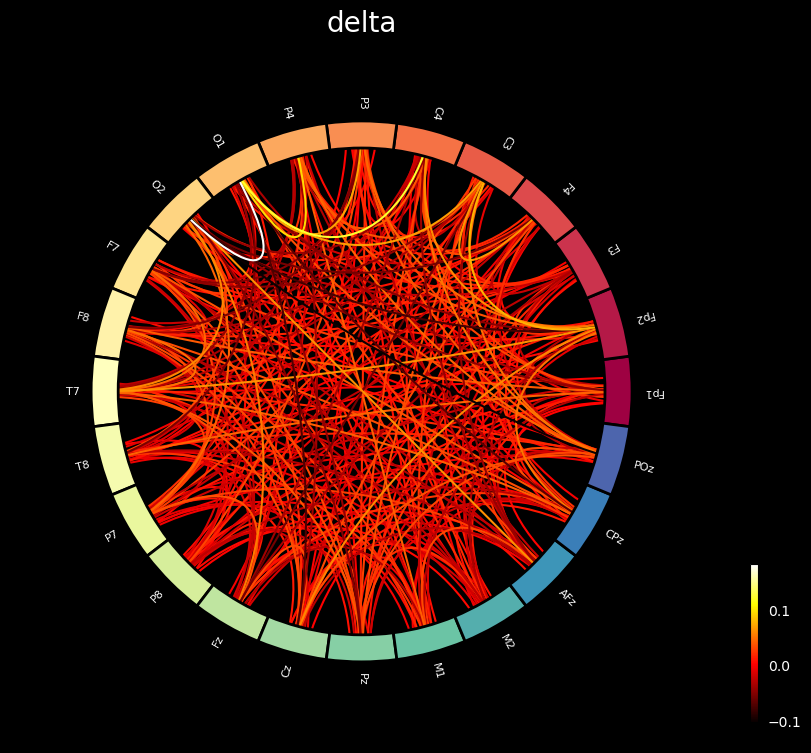

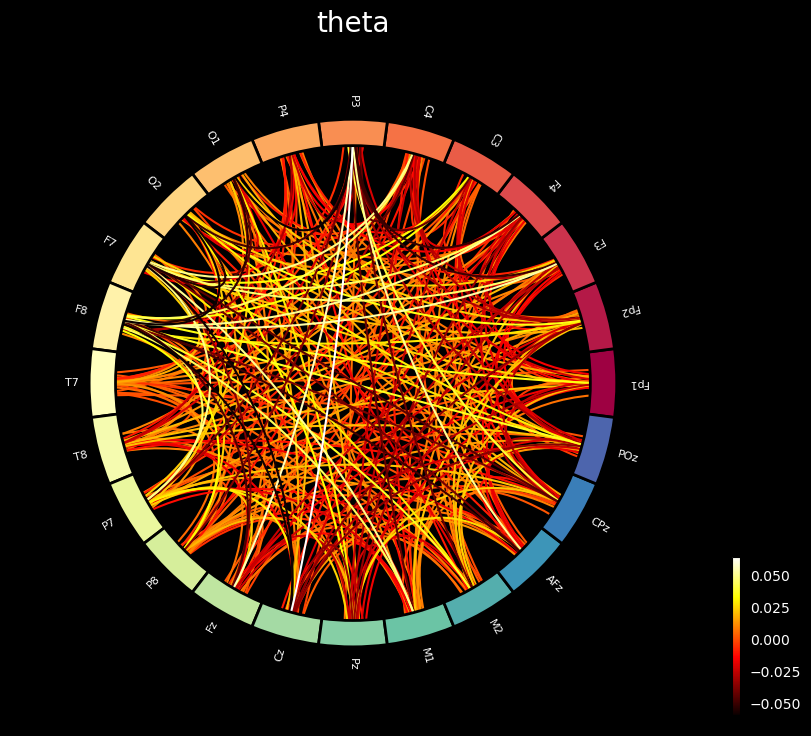

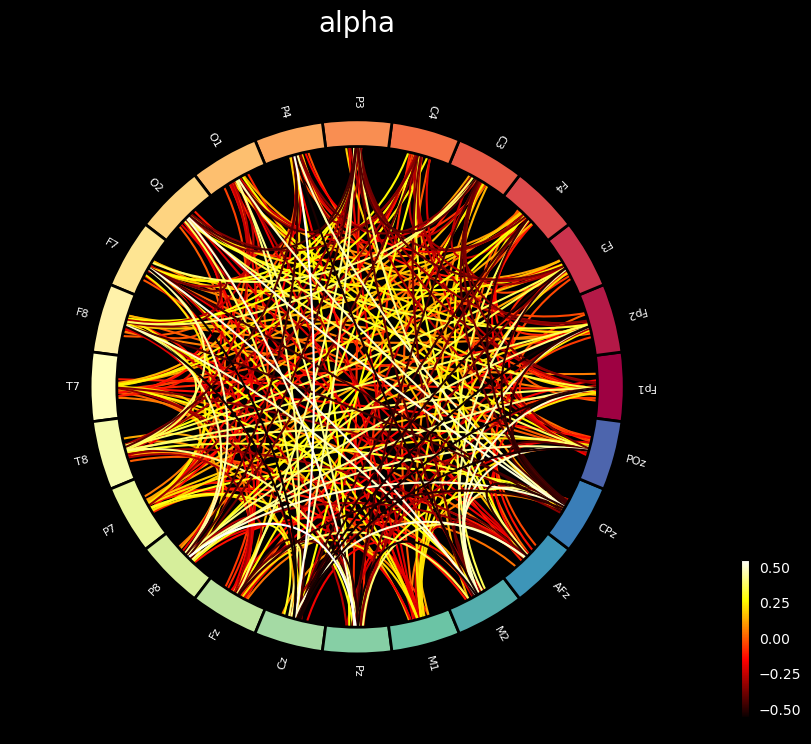

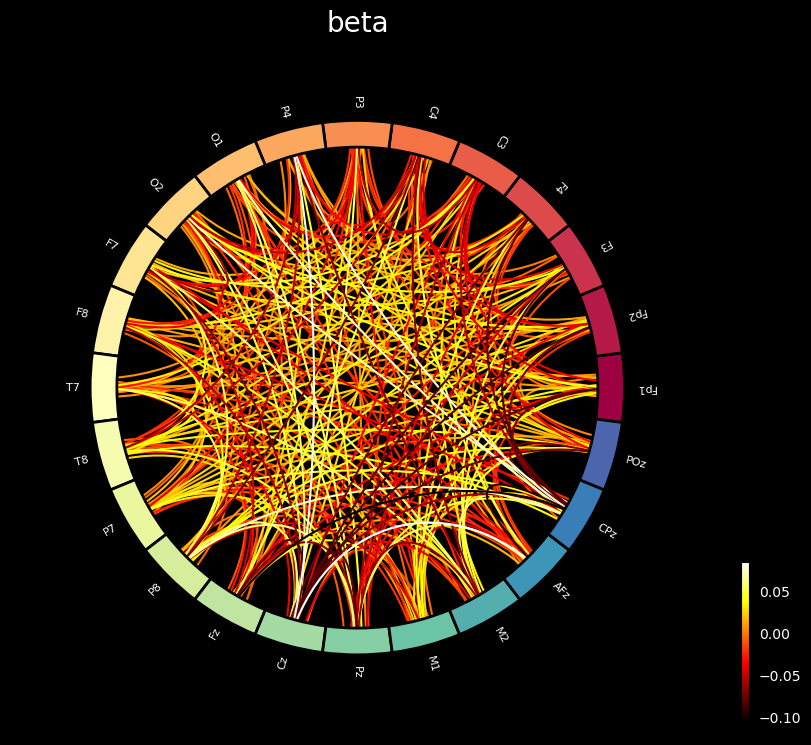

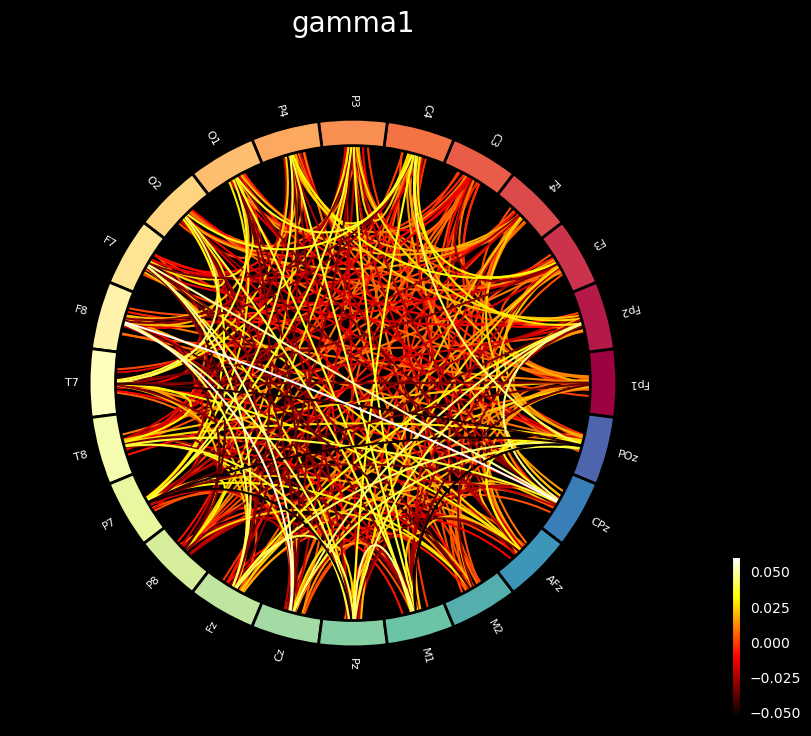

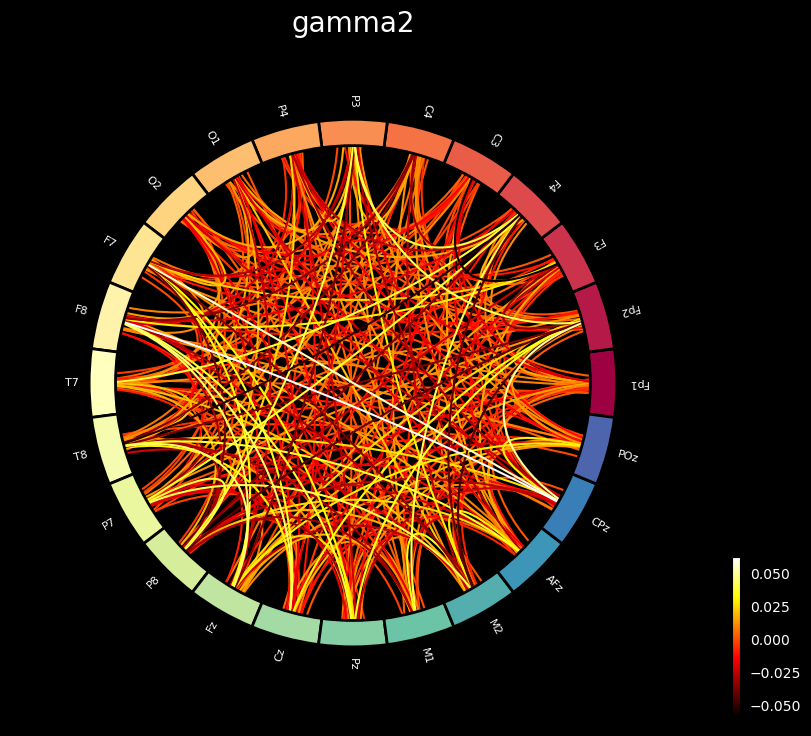

In [22]:
from mne_connectivity.viz import plot_connectivity_circle

for band in channel_coherence['S01']:
    conn = np.squeeze( channel_coherence['S01'][band].get_data( output='dense' ) )
    plot_connectivity_circle( conn, 
                             eeg_data['S01'].ch_names,
                             n_lines = 300,
                             title = band,
                             fontsize_title = 20,
                             padding = 3,
                             fontsize_colorbar = 10,
                             )


Nonlinear metrics: Spectral Entropy

In [23]:
from mne_features.univariate import compute_spect_entropy

def compute_entropy( eeg ):
    eeg_spect = np.transpose( eeg.get_data(), ( 1, 0, 2 ) ).reshape( 24, -1 )
    freq = eeg.info['sfreq']
    spect_entropy = compute_spect_entropy( sfreq = freq, data = eeg_spect )
    return spect_entropy

In [24]:
spectral_entropy = {}
mean_spectral_entropy = []

for s in eeg_data:
    entropy = compute_entropy( eeg_data[s] )
    spectral_entropy[s] = entropy


for subject in spectral_entropy:
    mean_entropy = np.mean( spectral_entropy[subject] ).round( 3 )
    mean_spectral_entropy.append( mean_entropy )

In [27]:
spectral_entropy_df = pd.DataFrame( spectral_entropy )
spectral_entropy_df.to_csv( dir+"/spectral_entropy.csv")

In [25]:
d = { 
    'DMT-Previous Experiences': dmt_exp,
    'Mean-PSD-pre-alpha': pre_alpha_m,
    'Mean-PSD-pre-beta': pre_beta_m,
    'Mean-PSD-pre-delta': pre_delta_m,
    'Mean-PSD-pre-gamma1': pre_gamma1_m,
    'Mean-PSD-pre-gamma2': pre_gamma2_m,
    'Mean-PSD-pre-theta': pre_theta_m,
    'Mean-PSD-dmt-alpha': dmt_alpha_m,
    'Mean-PSD-dmt-beta': dmt_beta_m,
    'Mean-PSD-dmt-delta': dmt_delta_m,
    'Mean-PSD-dmt-gamma1': dmt_gamma1_m,
    'Mean-PSD-dmt-gamma2': dmt_gamma2_m,
    'Mean-PSD-dmt-theta': dmt_theta_m,
    'Coherence-P8-Cz-beta': beta_P8_Cz,
    'Coherence-P8-Pz-beta': beta_P8_Pz,
    'Coherence-F7-Cz-gamma1': gamma1_F7_Cz,
    'Coherence-F8-Pz-gamma1': gamma1_F8_Pz,
    'Coherence-F8-POz-gamma1': gamma1_F8_POz,
    'Coherence-M1-CPz-gamma2': gamma2_M1_CPz,
    'Mean-spectral-entropy': mean_spectral_entropy
     }
df = pd.DataFrame( d )

In [26]:
df.to_csv( dir+"/dmt_data.csv")